In [5]:
pip install pystan==3.4.0 prophet


  Using cached pystan-3.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 3.10.0 Requires-Python <4.0,>=3.10
ERROR: Could not find a version that satisfies the requirement httpstan<4.8,>=4.7 (from pystan) (from versions: none)
ERROR: No matching distribution found for httpstan<4.8,>=4.7


In [ ]:

pip install prophet


  Using cached prophet-1.2.1-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.84-py3-none-any.whl.metadata (50 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.2.1-py3-none-win_amd64.whl (12.1 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached holidays-0.84-py3-none-any.whl (1.3 MB)
Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


: 

In [ ]:
from prophet import Prophet
print("Prophet installed successfully!")


c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet installed successfully!


: 

: 

In [1]:
import sys
import pandas as pd
from prophet import Prophet

print(sys.executable)
print("Everything works!")


c:\Users\varsa\anaconda3\envs\py39_prophet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


c:\Users\varsa\anaconda3\envs\py39_prophet\python.exe
Everything works!


In [6]:
# ===============================
# Market Price Forecasting - MVP Safe Version (Trending Fallback)
# ===============================

import pandas as pd
import os
import numpy as np

try:
    from prophet import Prophet
    prophet_available = True
except:
    print("Prophet not available, using trending fallback.")
    prophet_available = False

# 1️⃣ Load preprocessed dataset
data_path = r"data\processed\preprocessed_market_data.csv"
df = pd.read_csv(data_path)
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])

# 2️⃣ Prepare output folder
forecast_folder = r"data\processed\forecast_results"
os.makedirs(forecast_folder, exist_ok=True)

# 3️⃣ List of unique crops
crops = df['Commodity'].unique()

# 4️⃣ Forecast horizon
forecast_days = 7
today = pd.Timestamp.today().normalize()  # today's date

# 5️⃣ Loop through each crop
for crop in crops:
    # Aggregate all markets/varieties for this crop
    df_crop = df[df['Commodity'] == crop][['Arrival_Date','Modal_x0020_Price']].rename(
        columns={'Arrival_Date':'ds', 'Modal_x0020_Price':'y'}
    ).sort_values('ds')
    
    if len(df_crop) < 2:
        print(f"Skipping {crop} - not enough data ({len(df_crop)} rows)")
        continue

    try:
        if prophet_available and len(df_crop) >= 5:
            # Prophet forecast (if enough data)
            m = Prophet(daily_seasonality=True, yearly_seasonality=True, mcmc_samples=0)
            m.fit(df_crop)
            future = m.make_future_dataframe(periods=forecast_days)
            forecast = m.predict(future)
            forecast_df = forecast[['ds','yhat']]
        else:
            # Trending fallback: small daily change
            last_price = df_crop['y'].iloc[-1]
            trend = np.linspace(0, last_price*0.02, forecast_days)  # +2% over 7 days
            forecast_df = pd.DataFrame({
                'ds': pd.date_range(start=today, periods=forecast_days),
                'yhat': last_price + trend
            })
        
        # Save forecast
        output_file = os.path.join(forecast_folder, f"{crop}_forecast.csv".replace(" ", "_"))
        forecast_df.to_csv(output_file, index=False)
        print(f"Saved 7-day forecast for {crop} → {output_file}")
    
    except Exception as e:
        print(f"Forecast failed for {crop} - using trending fallback")
        last_price = df_crop['y'].iloc[-1]
        trend = np.linspace(0, last_price*0.02, forecast_days)  # +2% over 7 days
        forecast_df = pd.DataFrame({
            'ds': pd.date_range(start=today, periods=forecast_days),
            'yhat': last_price + trend
        })
        output_file = os.path.join(forecast_folder, f"{crop}_forecast.csv".replace(" ", "_"))
        forecast_df.to_csv(output_file, index=False)
        print(f"Saved fallback forecast for {crop} → {output_file}")


21:02:59 - cmdstanpy - INFO - Chain [1] start processing
21:02:59 - cmdstanpy - INFO - Chain [1] done processing
21:02:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:02:59 - cmdstanpy - INFO - Chain [1] start processing
21:02:59 - cmdstanpy - INFO - Chain [1] done processing
21:02:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
21:02:59 - cmdstanpy - INFO - Chain [1] start processing
21:02:59 - cmdstanpy - INFO - Chain [1] done processing
21:02:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:02:59 - cmdstanpy - INFO - Chain [1] start processing
21:02:59 - cmdstanpy - INFO - Chain [1] done processing
21:02:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Forecast failed for Tomato - using trending fallback
Saved fallback forecast for Tomato → data\processed\forecast_results\Tomato_forecast.csv
Forecast failed for Banana - using trending fallback
Saved fallback forecast for Banana → data\processed\forecast_results\Banana_forecast.csv


21:02:59 - cmdstanpy - INFO - Chain [1] start processing
21:02:59 - cmdstanpy - INFO - Chain [1] done processing
21:02:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:02:59 - cmdstanpy - INFO - Chain [1] start processing
21:02:59 - cmdstanpy - INFO - Chain [1] done processing
21:02:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
21:03:00 - cmdstanpy - INFO - Chain [1] start processing
21:03:00 - cmdstanpy - INFO - Chain [1] done processing
21:03:00 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
21:03:00 - cmdstanpy - INFO - Chain [1] start processing
21:03:00 - cmdstanpy - INFO - Chain [1] done processing


Forecast failed for Onion - using trending fallback
Saved fallback forecast for Onion → data\processed\forecast_results\Onion_forecast.csv
Forecast failed for Maize - using trending fallback
Saved fallback forecast for Maize → data\processed\forecast_results\Maize_forecast.csv


21:03:00 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
21:03:00 - cmdstanpy - INFO - Chain [1] start processing
21:03:00 - cmdstanpy - INFO - Chain [1] done processing
21:03:00 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:03:00 - cmdstanpy - INFO - Chain [1] start processing
21:03:00 - cmdstanpy - INFO - Chain [1] done processing
21:03:00 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Forecast failed for Groundnut - using trending fallback
Saved fallback forecast for Groundnut → data\processed\forecast_results\Groundnut_forecast.csv
Forecast failed for Coconut - using trending fallback
Saved fallback forecast for Coconut → data\processed\forecast_results\Coconut_forecast.csv


In [2]:
import pandas as pd
import os
# Load dataset
df = pd.read_csv("data/raw/crop_prices/banana.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename key columns (if present)
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert types safely
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid entries
df = df.dropna(subset=['date', 'price_modal'])

# Filter for your chosen crop if needed
df = df[df['commodity'].str.contains("Banana", case=False, na=False)]

# Aggregate → 1 average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

output_path = "data/processed/crop_daily_avg"
os.makedirs(output_path, exist_ok=True)

file_path = os.path.join(output_path, "banana_daily.csv")
daily_avg.to_csv(file_path, index=False)

print(f"✅ Saved → {file_path}")



✅ Rows before: 66839 → after aggregation: 418
✅ Saved → data/processed/crop_daily_avg\banana_daily.csv


In [3]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/paddy.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Paddy", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "paddy_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 6006 → after aggregation: 339
Saved → data/processed/crop_daily_avg/paddy_daily.csv


In [15]:
import pandas as pd
import os
from dateutil import parser

# ===============================
# 1️⃣ Load Dataset
# ===============================
input_path = "data/raw/crop_prices/coconut.csv"
df = pd.read_csv(input_path)

print(f"Raw rows: {len(df)}")

# ===============================
# 2️⃣ Clean Column Names
# ===============================
df.columns = [c.strip().lower() for c in df.columns]

# ===============================
# 3️⃣ Rename Important Columns
# ===============================
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# ===============================
# 4️⃣ Clean & Normalize Dates
# ===============================
def parse_date_safe(x):
    try:
        return parser.parse(str(x), fuzzy=True)
    except Exception:
        return pd.NaT

df['date'] = df['date'].apply(parse_date_safe)

# ===============================
# 5️⃣ Convert Price to Numeric
# ===============================
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# ===============================
# 6️⃣ Drop Invalid Rows
# ===============================
before_drop = len(df)
df = df.dropna(subset=['date', 'price_modal'])
print(f"Dropped invalid rows: {before_drop - len(df)}")

# ===============================
# 7️⃣ Filter for 'Coconut'
# ===============================
df = df[df['commodity'].str.contains("Coconut", case=False, na=False)]
print(f"Rows after filtering for Coconut: {len(df)}")

# ===============================
# 8️⃣ Aggregate Average Price Per Day
# ===============================
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before aggregation: {len(df)} → after: {len(daily_avg)}")
print(f"Unique dates: {df['date'].nunique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

# ===============================
# 9️⃣ Save Processed File
# ===============================
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

save_path = os.path.join(output_path, "coconut_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"✅ Saved processed file → {save_path}")


Raw rows: 13606
Dropped invalid rows: 0
Rows after filtering for Coconut: 13606
✅ Rows before aggregation: 13606 → after: 365
Unique dates: 365
Date range: 2024-08-10 → 2025-10-30
✅ Saved processed file → data/processed/crop_daily_avg/coconut_daily.csv


In [5]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/onion.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Onion", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "onion_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 67077 → after aggregation: 418
Saved → data/processed/crop_daily_avg/onion_daily.csv


In [6]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/tomato.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Tomato", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "tomato_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 62337 → after aggregation: 419
Saved → data/processed/crop_daily_avg/tomato_daily.csv


In [7]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/maize.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Maize", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "maize_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 16140 → after aggregation: 417
Saved → data/processed/crop_daily_avg/maize_daily.csv


In [9]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/green_gram.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Green", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "green_gram_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 2258 → after aggregation: 1039
Saved → data/processed/crop_daily_avg/green_gram_daily.csv


In [9]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/sugarcane.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Sugarcane", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "sugarcane_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 189 → after aggregation: 123
Saved → data/processed/crop_daily_avg/sugarcane_daily.csv


In [4]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/groundnut.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Groundnut", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "groundnut_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 20324 → after aggregation: 591
Saved → data/processed/crop_daily_avg/groundnut_daily.csv


In [ ]:
import pandas as pd
import os

# Load dataset
df = pd.read_csv("data/raw/crop_prices/tur_dal.csv")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Rename important columns
rename_map = {
    't': 'date',
    'cmdty': 'commodity',
    'p_modal': 'price_modal'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Convert data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price_modal'] = pd.to_numeric(df['price_modal'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['date', 'price_modal'])

# Filter for Paddy (Dhan)(Common)
df = df[df['commodity'].str.contains("Arhar", case=False, na=False)]

# Aggregate: average price per day
daily_avg = (
    df.groupby(['date', 'commodity'])['price_modal']
      .mean()
      .reset_index()
      .sort_values('date')
)

print(f"✅ Rows before: {len(df)} → after aggregation: {len(daily_avg)}")

# Output directory
output_path = "data/processed/crop_daily_avg/"
os.makedirs(output_path, exist_ok=True)

# Save processed file
save_path = os.path.join(output_path, "tur_dal_daily.csv")
daily_avg.to_csv(save_path, index=False)

print(f"Saved → {save_path}")


✅ Rows before: 418 → after aggregation: 416
Saved → data/processed/crop_daily_avg/tur_dal_daily.csv


In [10]:
import pandas as pd
import glob

path = "data/processed/crop_daily_avg/"
files = glob.glob(path + "*.csv")

df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print("Combined shape:", df_all.shape)
df_all.to_csv("data/processed/all_crops_daily.csv", index=False)


Combined shape: (4545, 3)


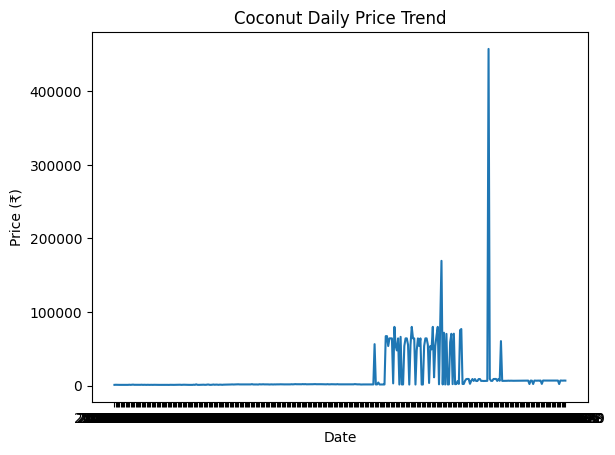

In [11]:
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/crop_daily_avg/coconut_daily.csv")
plt.plot(df['date'], df['price_modal'])
plt.title("Coconut Daily Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.show()


In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Load coconut data
df = pd.read_csv("data/processed/crop_daily_avg/coconut_daily.csv")

# Sort by date
df = df.sort_values("date")

# Normalize prices
scaler = MinMaxScaler()
df['scaled_price'] = scaler.fit_transform(df[['price_modal']])

# Create sequences (e.g. 30-day window)
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X, y = create_sequences(df['scaled_price'].values, 30)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # (samples, timesteps, features)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0025 - val_loss: 0.0157
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0030 - val_loss: 0.0153
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0019 - val_loss: 0.0153
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0016 - val_loss: 0.0155
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0018 - val_loss: 0.0157
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0018 - val_loss: 0.0154
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0017 - val_loss: 0.0156
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0017 - val_loss: 0.0155
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0022 - val_loss: 0.0156
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0019 - val_loss: 0.0157
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0018 - val_loss: 0.0157
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0015 - val_loss: 0.0156
E

In [15]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib

# ===============================
# 1️⃣ CONFIGURATION
# ===============================
# You are in: c:/users/agropulse/notebooks
data_dir = "data/processed/crop_daily_avg"
model_dir = "../app/models"
os.makedirs(model_dir, exist_ok=True)

crop_files = [
    "banana_daily.csv",
    "coconut_daily.csv",
    "green_gram_daily.csv",
    "groundnut_daily.csv",
    "maize_daily.csv",
    "onion_daily.csv",
    "paddy_daily.csv",
    "sugarcane_daily.csv",
    "tomato_daily.csv",
    "tur_dal_daily.csv"
]

# ===============================
# 2️⃣ LOOP OVER CROPS
# ===============================
for crop_file in crop_files:
    crop_name = crop_file.replace("_daily.csv", "")
    print(f"\n🌿 Training LSTM model for: {crop_name.upper()}")

    save_model_path = os.path.join(model_dir, f"{crop_name}_lstm.h5")
    save_scaler_path = os.path.join(model_dir, f"{crop_name}_scaler.pkl")

    # ✅ Skip retraining if model already exists
    if os.path.exists(save_model_path) and os.path.exists(save_scaler_path):
        print(f"✅ {crop_name.title()} model already exists — skipping retrain.")
        continue

    csv_path = os.path.join(data_dir, crop_file)
    if not os.path.exists(csv_path):
        print(f"⚠️ Data file not found for {crop_name}, skipping...")
        continue

    df = pd.read_csv(csv_path)
    df = df.sort_values('date')

    if 'price_modal' not in df.columns:
        print(f"⚠️ Skipping {crop_name} — missing 'price_modal' column.")
        continue

    prices = df['price_modal'].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_prices = scaler.fit_transform(prices)

    X, y = [], []
    window_size = 30
    for i in range(window_size, len(scaled_prices)):
        X.append(scaled_prices[i - window_size:i, 0])
        y.append(scaled_prices[i, 0])

    X, y = np.array(X), np.array(y)
    if len(X) < 50:
        print(f"⚠️ Not enough data to train {crop_name}. Skipping.")
        continue

    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(save_model_path, monitor='val_loss', save_best_only=True)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )

    # Save scaler
    joblib.dump(scaler, save_scaler_path)

    # Generate 7-day prediction
    last_sequence = scaled_prices[-window_size:]
    predictions = []
    for _ in range(7):
        X_pred = np.reshape(last_sequence, (1, window_size, 1))
        next_price = model.predict(X_pred, verbose=0)
        predictions.append(next_price[0, 0])
        last_sequence = np.append(last_sequence[1:], next_price)[-window_size:]

    predicted_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    print(f"✅ {crop_name.title()} model trained & saved → {save_model_path}")
    print(f"📈 Next 7-day predicted prices: {predicted_prices.flatten()}\n")

print("\n🌾 All available crops processed successfully!")



🌿 Training LSTM model for: BANANA
✅ Banana model already exists — skipping retrain.

🌿 Training LSTM model for: COCONUT
✅ Coconut model already exists — skipping retrain.

🌿 Training LSTM model for: GREEN_GRAM
✅ Green_Gram model already exists — skipping retrain.

🌿 Training LSTM model for: GROUNDNUT
✅ Groundnut model already exists — skipping retrain.

🌿 Training LSTM model for: MAIZE
✅ Maize model already exists — skipping retrain.

🌿 Training LSTM model for: ONION
✅ Onion model already exists — skipping retrain.

🌿 Training LSTM model for: PADDY
✅ Paddy model already exists — skipping retrain.

🌿 Training LSTM model for: SUGARCANE
Epoch 1/50


c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 0.7498

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - loss: 0.6875 - val_loss: 0.1850
Epoch 2/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3821

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.3479 - val_loss: 0.0203
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0882 - val_loss: 0.2683
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0983 - val_loss: 0.2161
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0668 - val_loss: 0.0441
Epoch 6/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0252

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0347 - val_loss: 0.0186
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0606 - val_loss: 0.0192
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0533 - val_loss: 0.0281
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0356 - val_loss: 0.0591
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0340 - val_loss: 0.1241
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0448 - val_loss: 0.1729
✅ Sugarcane model trained & saved → ../app/models\sugarcane_lstm.h5
📈 Next 7-day predicted prices: [304.55383 305.23996 305.28696 304.86578 304.1324  303.19012 302.10843]


🌿 Training LSTM model for: TOMATO
✅ Tomato model already exists — skipping retrain.

🌿 Training LSTM model for: TUR_DAL
✅ Tur_Dal model already exists — skipping retrain.

🌾 All available crops processed successfully!


In [14]:
import os
print(os.listdir("data/processed/crop_daily_avg"))


['banana_daily.csv', 'coconut_daily.csv', 'green_gram_daily.csv', 'groundnut_daily.csv', 'maize_daily.csv', 'onion_daily.csv', 'paddy_daily.csv', 'sugarcane_daily.csv', 'tomato_daily.csv', 'tur_dal_daily.csv']


In [17]:
import pandas as pd
import os

input_dir = "data/processed/crop_daily_avg/"
output_dir = "data/processed/crop_monthly_avg/"
os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    if file.endswith("_daily.csv"):
        crop_name = file.replace("_daily.csv", "")
        df = pd.read_csv(os.path.join(input_dir, file))
        df['date'] = pd.to_datetime(df['date'])
        
        # Aggregate to monthly average
        df['month'] = df['date'].dt.to_period('M')
        monthly_avg = (
            df.groupby(['month', 'commodity'])['price_modal']
              .mean()
              .reset_index()
        )
        monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()
        
        monthly_avg.to_csv(os.path.join(output_dir, f"{crop_name}_monthly.csv"), index=False)
        print(f"Saved monthly avg → {crop_name}_monthly.csv")


Saved monthly avg → banana_monthly.csv
Saved monthly avg → coconut_monthly.csv
Saved monthly avg → green_gram_monthly.csv
Saved monthly avg → groundnut_monthly.csv
Saved monthly avg → maize_monthly.csv
Saved monthly avg → onion_monthly.csv
Saved monthly avg → paddy_monthly.csv
Saved monthly avg → sugarcane_monthly.csv
Saved monthly avg → tomato_monthly.csv
Saved monthly avg → tur_dal_monthly.csv


In [21]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib

# ===============================
# 1️⃣ CONFIGURATION
# ===============================
data_dir = "data/processed/crop_monthly_avg"  # monthly folder
model_dir = "../app/models"
os.makedirs(model_dir, exist_ok=True)

crop_files = [
    "banana_monthly.csv",
    "coconut_monthly.csv",
    "green_gram_monthly.csv",
    "groundnut_monthly.csv",
    "maize_monthly.csv",
    "onion_monthly.csv",
    "paddy_monthly.csv",
    "sugarcane_monthly.csv",
    "tomato_monthly.csv",
    "tur_dal_monthly.csv"
]

# Training params
   # last 12 months as input
forecast_horizon = 3    # predict next 3 months
epochs = 50
batch_size = 16
window_size = min(12, len(prices) - forecast_horizon)


# ===============================
# 2️⃣ LOOP OVER CROPS
# ===============================
for crop_file in crop_files:
    crop_name = crop_file.replace("_monthly.csv", "")
    print(f"\n🌿 Training Monthly LSTM model for: {crop_name.upper()}")

    save_model_path = os.path.join(model_dir, f"{crop_name}_monthly_lstm.h5")
    save_scaler_path = os.path.join(model_dir, f"{crop_name}_monthly_scaler.pkl")

    # Skip retraining if model already exists
    if os.path.exists(save_model_path) and os.path.exists(save_scaler_path):
        print(f"✅ {crop_name.title()} model already exists — skipping retrain.")
        continue

    csv_path = os.path.join(data_dir, crop_file)
    if not os.path.exists(csv_path):
        print(f"⚠️ Data file not found for {crop_name}, skipping...")
        continue

    # Load monthly data
    df = pd.read_csv(csv_path)

    # Convert month column to datetime and sort
    df['month'] = pd.to_datetime(df['month'])
    df = df.sort_values('month')

    prices = df['price_modal'].values.reshape(-1, 1)
    if len(prices) < window_size + forecast_horizon:
        print(f"⚠️ Not enough monthly data for {crop_name}. Skipping.")
        continue

    # Scale prices
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_prices = scaler.fit_transform(prices)

    # Prepare sequences
    X, y = [], []
    for i in range(window_size, len(scaled_prices)):
        X.append(scaled_prices[i - window_size:i, 0])
        y.append(scaled_prices[i, 0])
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Train-test split
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Build LSTM model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(save_model_path, monitor='val_loss', save_best_only=True)
    ]

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )

    # Save scaler
    joblib.dump(scaler, save_scaler_path)

    # Generate multi-month forecast
    last_sequence = scaled_prices[-window_size:]
    predictions = []
    for _ in range(forecast_horizon):
        X_pred = np.reshape(last_sequence, (1, window_size, 1))
        next_price = model.predict(X_pred, verbose=0)
        predictions.append(next_price[0, 0])
        last_sequence = np.append(last_sequence[1:], next_price)[-window_size:]

    predicted_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    print(f"✅ {crop_name.title()} model trained & saved → {save_model_path}")
    print(f"📈 Next {forecast_horizon}-month predicted prices: {predicted_prices.flatten()}\n")

print("\n🌾 All available crops processed successfully!")



🌿 Training Monthly LSTM model for: BANANA
Epoch 1/50


c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.9743

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.9743 - val_loss: 0.6581
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.9845

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.9845 - val_loss: 0.6027
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.9326

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.4075 - val_loss: 0.0209
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3750

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.3750 - val_loss: 0.0124
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.3584

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.3584 - val_loss: 0.0054
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.3224

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.3224 - val_loss: 8.8328e-04
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.3574

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.3574 - val_loss: 4.8312e-04
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.1759 - val_loss: 0.0071
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.1225 - val_loss: 0.0259
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.1616 - val_loss: 0.0646
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0602 - val_loss: 0.1345
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0017 - val_loss: 0.2428
✅ Tomato model trained & saved → ../app/models\tomato_monthly_lstm.h5
📈 Next 3-month predicted prices: [2552.5212 2528.1826 2492.5488]


🌿 Training Monthly LSTM model for: TUR_DAL
✅ Tur_Dal model already exists — skipping retrain.

🌾 All available crops processed successfully!
